In [1]:
!pip install pyspark


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, mean, when, isnull

In [3]:
spark = SparkSession.builder \
                    .appName("Tutorial_DF") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()

In [4]:
file_path = "/content/Airline_Delay_Cause (1).csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Show the first 5 rows
print("Showing first 5 rows:")
df.show(5)

# Print schema of the DataFrame
print("Schema of DataFrame:")
df.printSchema(1)

Showing first 5 rows:
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        

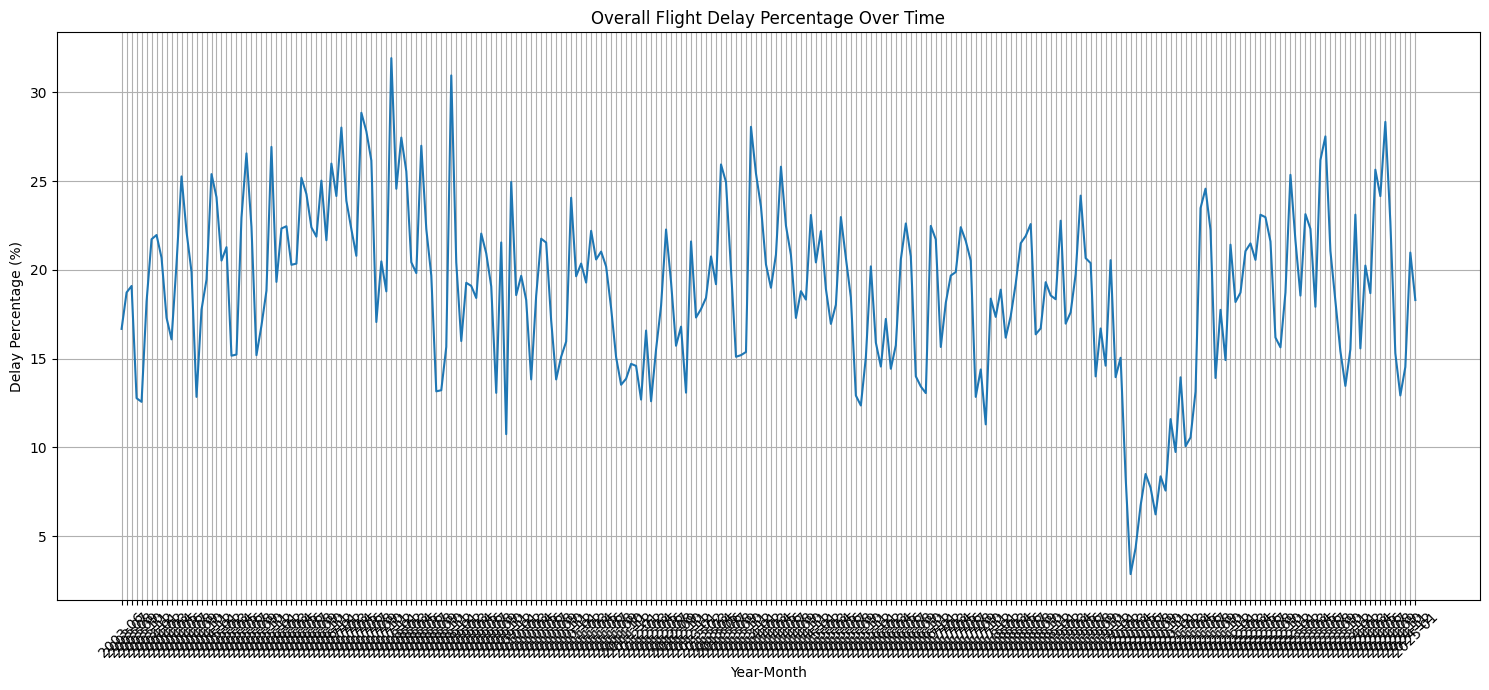

In [5]:
from pyspark.sql.functions import sum, col
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and month, then calculate total delays and total flights
delay_trends_df = df.groupBy('year', 'month') \
                      .agg(sum('arr_del15').alias('total_delays'), \
                           sum('arr_flights').alias('total_flights')) \
                      .orderBy('year', 'month')

# Calculate delay percentage
delay_trends_df = delay_trends_df.withColumn(
    'delay_percentage',
    (col('total_delays') / col('total_flights')) * 100
)

# Convert to Pandas DataFrame for plotting
pandas_delay_trends = delay_trends_df.toPandas()

# Create a 'year_month' column for better plotting
pandas_delay_trends['year_month'] = pandas_delay_trends['year'].astype(str) + '-' + pandas_delay_trends['month'].astype(str).str.zfill(2)

# Plotting the data
plt.figure(figsize=(15, 7))
sns.lineplot(x='year_month', y='delay_percentage', data=pandas_delay_trends)
plt.title('Overall Flight Delay Percentage Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Delay Percentage (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

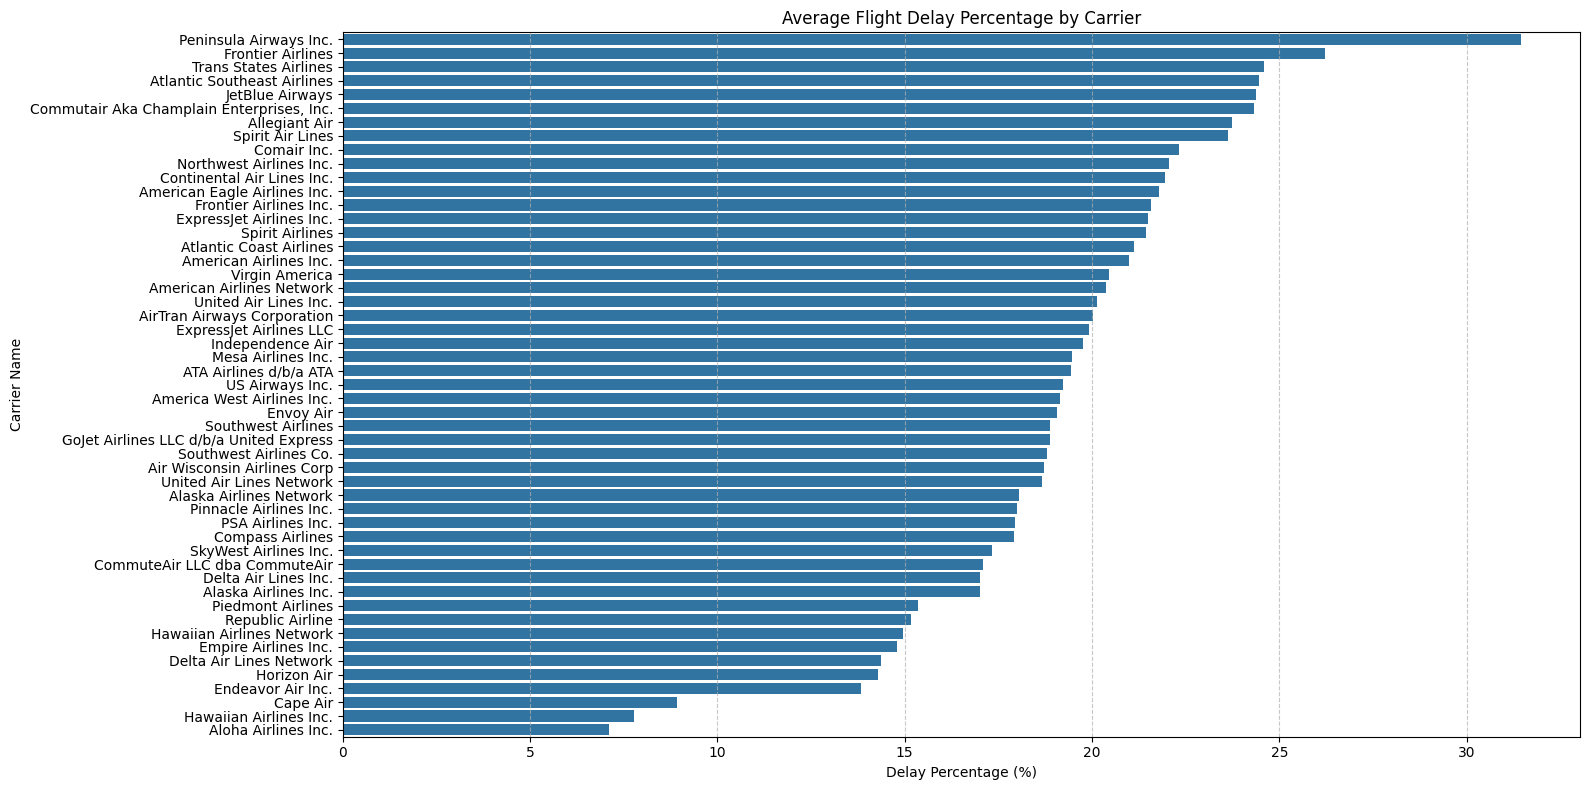

In [6]:
from pyspark.sql.functions import sum, col
import matplotlib.pyplot as plt
import seaborn as sns

# Group by carrier_name and calculate total delayed flights and total flights
carrier_delay_df = df.groupBy('carrier_name') \
                       .agg(sum('arr_del15').alias('total_delays'), \
                            sum('arr_flights').alias('total_flights'))

# Calculate delay percentage for each carrier
carrier_delay_df = carrier_delay_df.withColumn(
    'delay_percentage',
    (col('total_delays') / col('total_flights')) * 100
)

# Order by delay percentage in descending order
carrier_delay_df = carrier_delay_df.orderBy(col('delay_percentage').desc())

# Convert to Pandas DataFrame for plotting
pandas_carrier_delay = carrier_delay_df.toPandas()

# Plotting the data
plt.figure(figsize=(16, 8))
sns.barplot(x='delay_percentage', y='carrier_name', data=pandas_carrier_delay)
plt.title('Average Flight Delay Percentage by Carrier')
plt.xlabel('Delay Percentage (%)')
plt.ylabel('Carrier Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

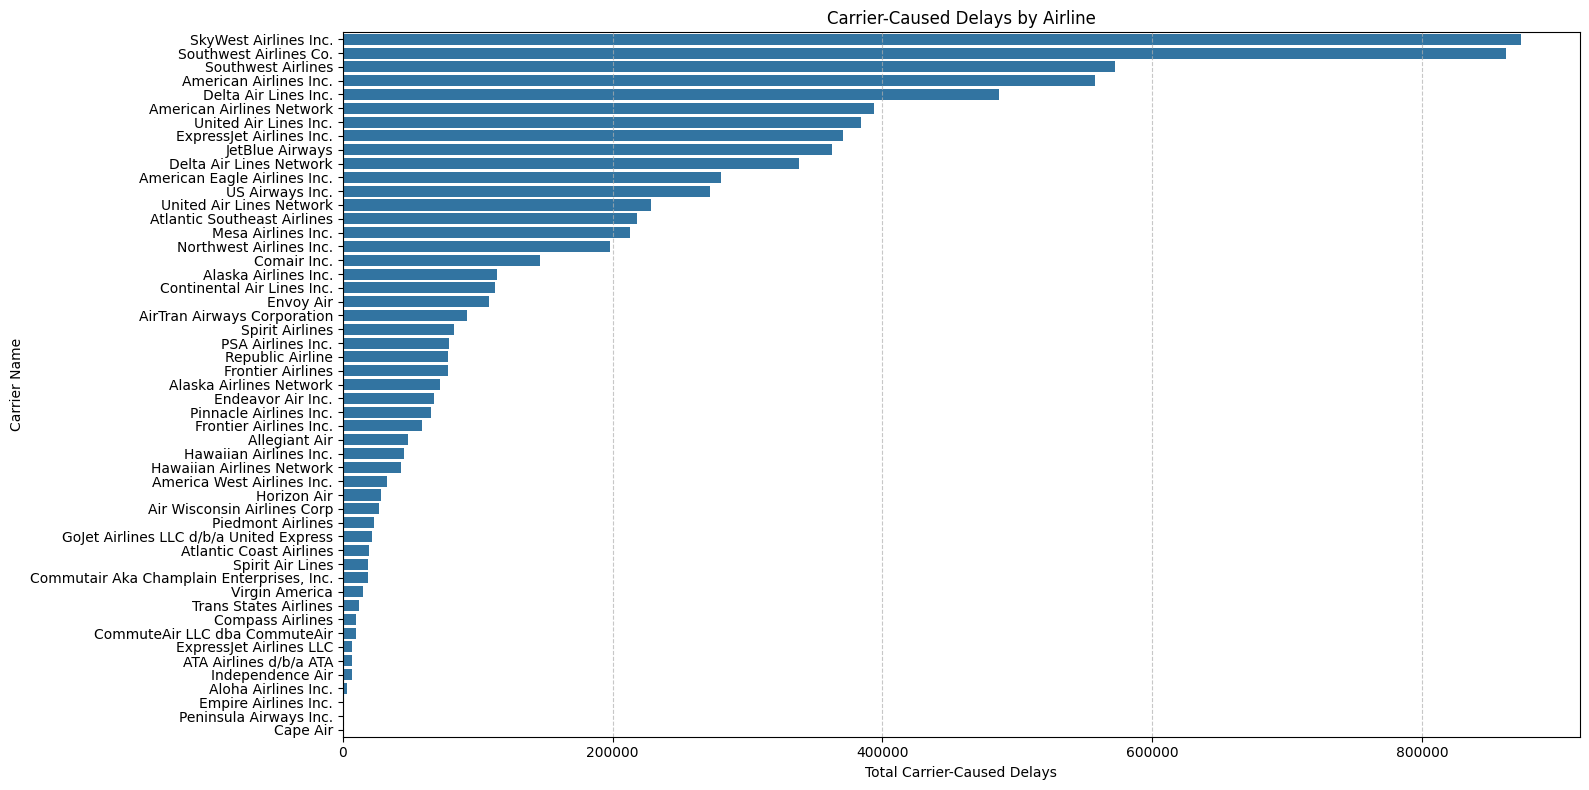

In [7]:
from pyspark.sql.functions import sum
import matplotlib.pyplot as plt
import seaborn as sns

# Group by carrier_name and calculate total carrier_ct (carrier-caused delays)
carrier_ct_df = df.groupBy('carrier_name') \
                    .agg(sum('carrier_ct').alias('total_carrier_delays')) \
                    .orderBy(col('total_carrier_delays').desc())

# Convert to Pandas DataFrame for plotting
pandas_carrier_ct = carrier_ct_df.toPandas()

# Plotting the data
plt.figure(figsize=(16, 8))
sns.barplot(x='total_carrier_delays', y='carrier_name', data=pandas_carrier_ct)
plt.title('Carrier-Caused Delays by Airline')
plt.xlabel('Total Carrier-Caused Delays')
plt.ylabel('Carrier Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

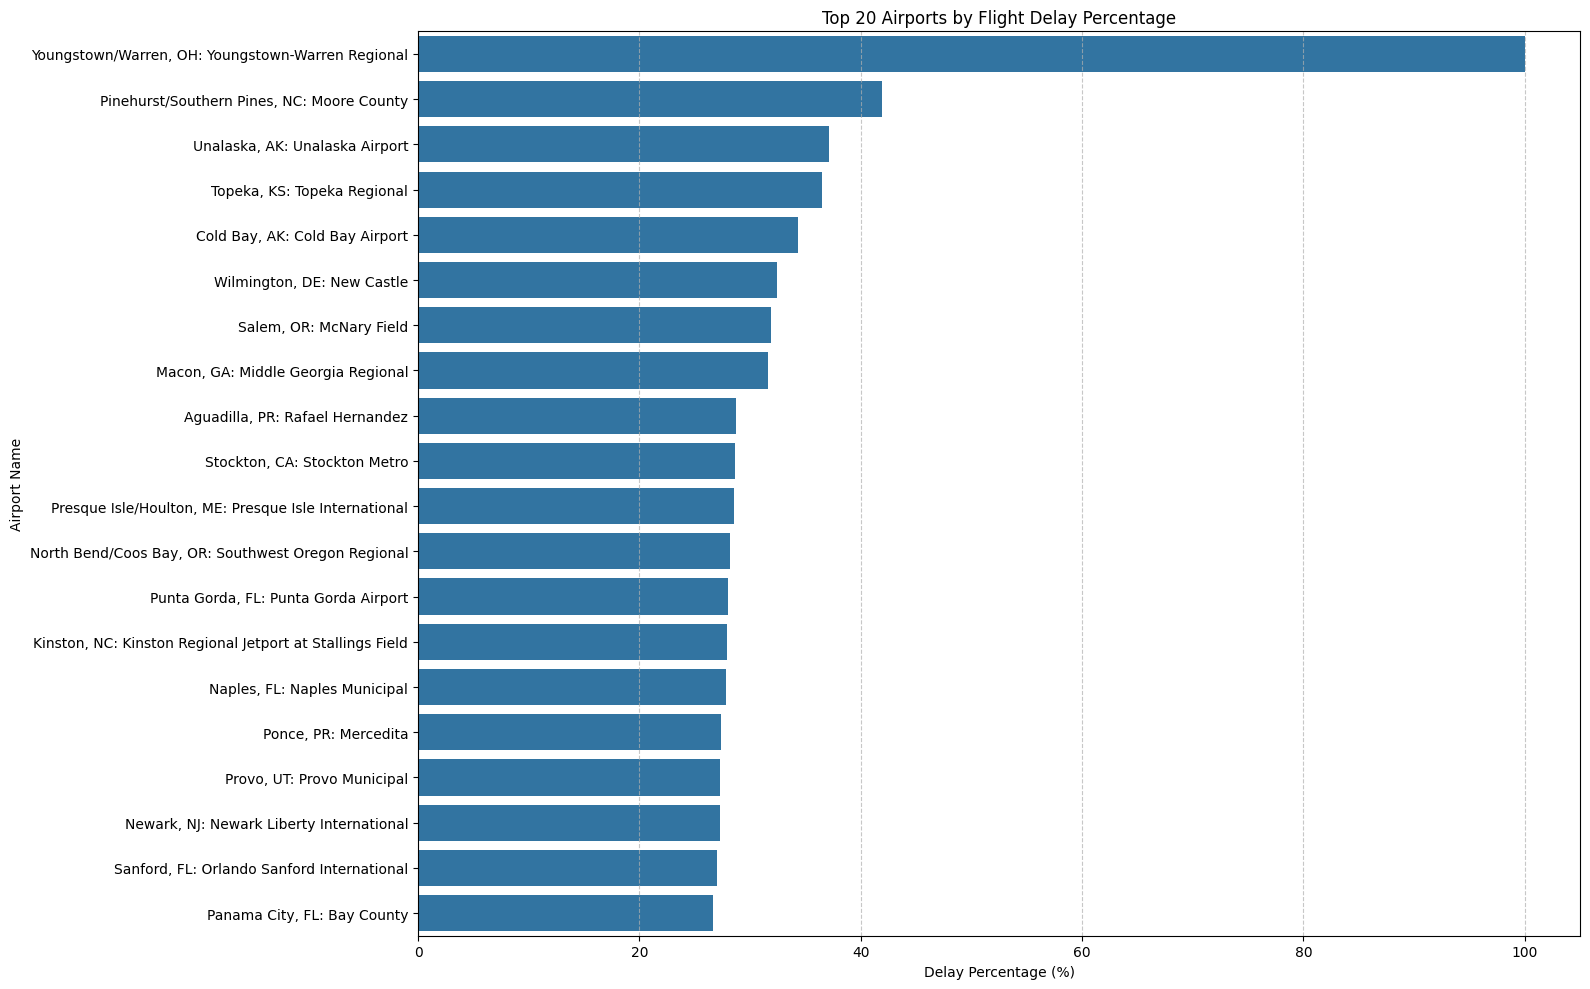

In [8]:
from pyspark.sql.functions import sum, col
import matplotlib.pyplot as plt
import seaborn as sns

# Group by airport_name and calculate total delayed flights and total flights
airport_delay_df = df.groupBy('airport_name') \
                       .agg(sum('arr_del15').alias('total_delays'), \
                            sum('arr_flights').alias('total_flights'))

# Calculate delay percentage for each airport
airport_delay_df = airport_delay_df.withColumn(
    'delay_percentage',
    (col('total_delays') / col('total_flights')) * 100
)

# Order by delay percentage in descending order and take the top N airports for better visualization
# Let's consider the top 20 airports for clarity in the bar chart
N = 20
airport_delay_df = airport_delay_df.orderBy(col('delay_percentage').desc()).limit(N)

# Convert to Pandas DataFrame for plotting
pandas_airport_delay = airport_delay_df.toPandas()

# Plotting the data
plt.figure(figsize=(16, 10))
sns.barplot(x='delay_percentage', y='airport_name', data=pandas_airport_delay)
plt.title(f'Top {N} Airports by Flight Delay Percentage')
plt.xlabel('Delay Percentage (%)')
plt.ylabel('Airport Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

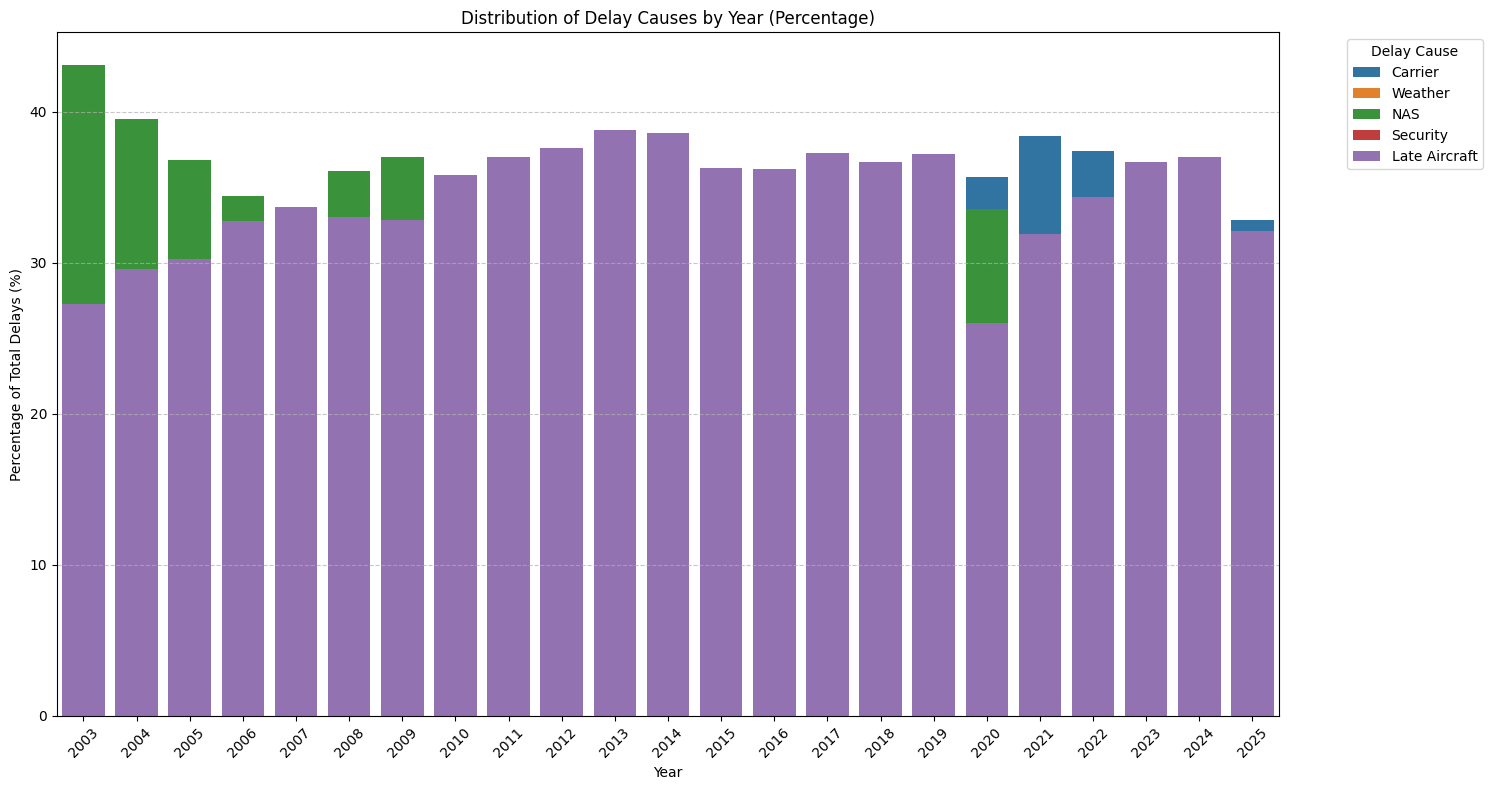

In [10]:
from pyspark.sql.functions import sum, col
import matplotlib.pyplot as plt
import seaborn as sns

# Group by year and sum up each delay cause
yearly_causes_df = df.groupBy('year').agg(
    sum('carrier_ct').alias('Carrier Caused Delays'),
    sum('weather_ct').alias('Weather Caused Delays'),
    sum('nas_ct').alias('National Airspace System Delays'),
    sum('security_ct').alias('Security Caused Delays'),
    sum('late_aircraft_ct').alias('Late Aircraft Delays')
).orderBy('year')

# Convert to Pandas DataFrame
pandas_yearly_causes = yearly_causes_df.toPandas()

# Calculate the total delays for each year
pandas_yearly_causes['Total Delays'] = pandas_yearly_causes[['Carrier Caused Delays', 'Weather Caused Delays', 'National Airspace System Delays', 'Security Caused Delays', 'Late Aircraft Delays']].sum(axis=1)

# Calculate the percentage of each delay cause for each year
for cause in ['Carrier Caused Delays', 'Weather Caused Delays', 'National Airspace System Delays', 'Security Caused Delays', 'Late Aircraft Delays']:
    pandas_yearly_causes[f'{cause}_Pct'] = (pandas_yearly_causes[cause] / pandas_yearly_causes['Total Delays']) * 100

# Select only the percentage columns and the year
pandas_yearly_causes_pct = pandas_yearly_causes[['year', 'Carrier Caused Delays_Pct', 'Weather Caused Delays_Pct', 'National Airspace System Delays_Pct', 'Security Caused Delays_Pct', 'Late Aircraft Delays_Pct']]

# Rename columns for better plotting
pandas_yearly_causes_pct.columns = ['Year', 'Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']

# Reshape to long format for stacked bar chart
pandas_yearly_causes_melted = pandas_yearly_causes_pct.melt(id_vars=['Year'], var_name='Delay Cause', value_name='Percentage')

# Plotting the data as a stacked bar chart
plt.figure(figsize=(15, 8))
sns.barplot(x='Year', y='Percentage', hue='Delay Cause', data=pandas_yearly_causes_melted, dodge=False)
plt.title('Distribution of Delay Causes by Year (Percentage)')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Delays (%)')
plt.xticks(rotation=45)
plt.legend(title='Delay Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

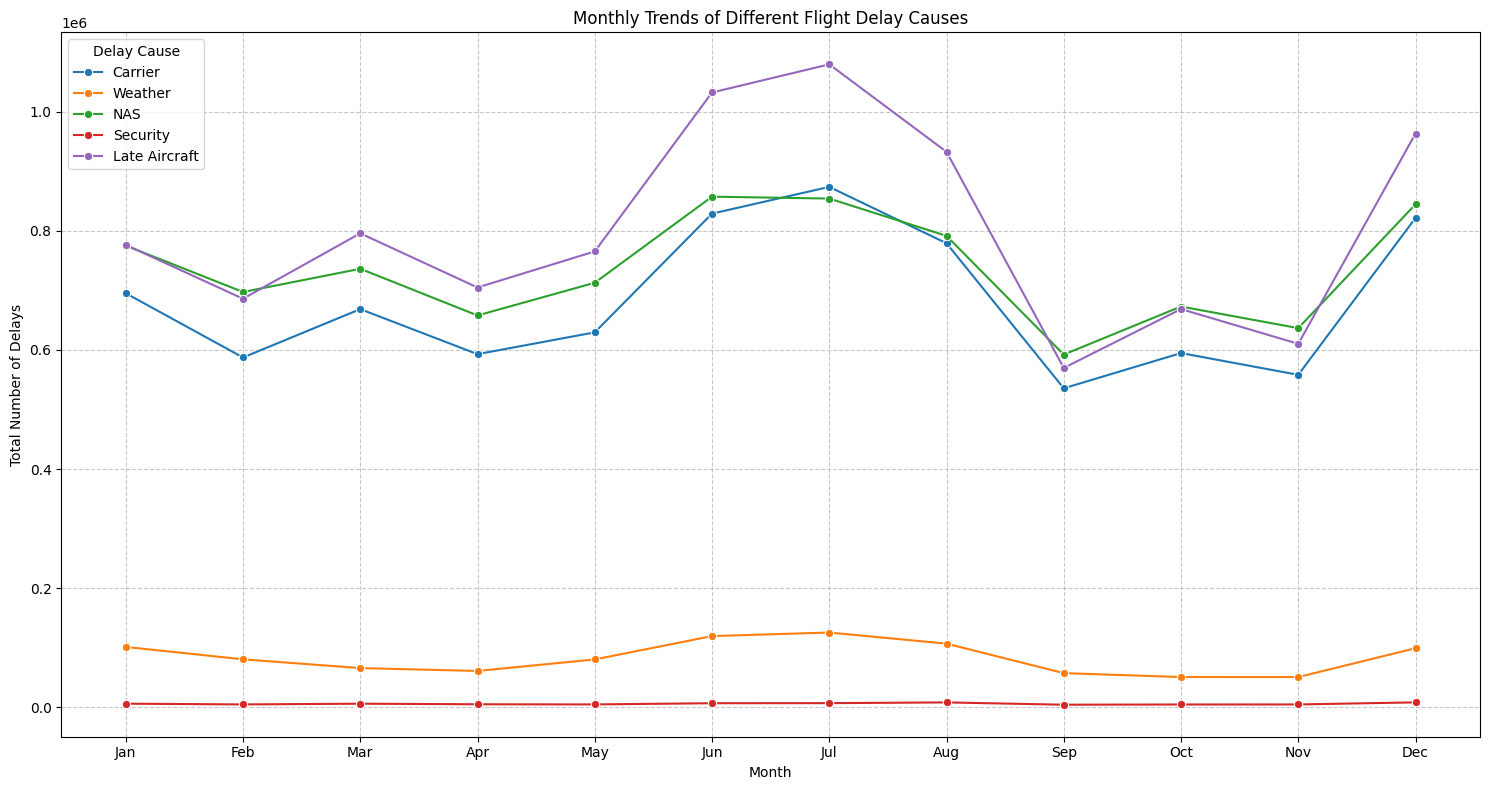

In [11]:
from pyspark.sql.functions import sum
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by month and sum up each delay cause
monthly_causes_df = df.groupBy('month').agg(
    sum('carrier_ct').alias('Carrier'),
    sum('weather_ct').alias('Weather'),
    sum('nas_ct').alias('NAS'),
    sum('security_ct').alias('Security'),
    sum('late_aircraft_ct').alias('Late Aircraft')
).orderBy('month')

# Convert to Pandas DataFrame
pandas_monthly_causes = monthly_causes_df.toPandas()

# Reshape to long format for multi-line plotting
pandas_monthly_causes_melted = pandas_monthly_causes.melt(id_vars=['month'], var_name='Delay Cause', value_name='Total Delays')

# Plotting the data
plt.figure(figsize=(15, 8))
sns.lineplot(x='month', y='Total Delays', hue='Delay Cause', data=pandas_monthly_causes_melted, marker='o')
plt.title('Monthly Trends of Different Flight Delay Causes')
plt.xlabel('Month')
plt.ylabel('Total Number of Delays')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Delay Cause')
plt.tight_layout()
plt.show()

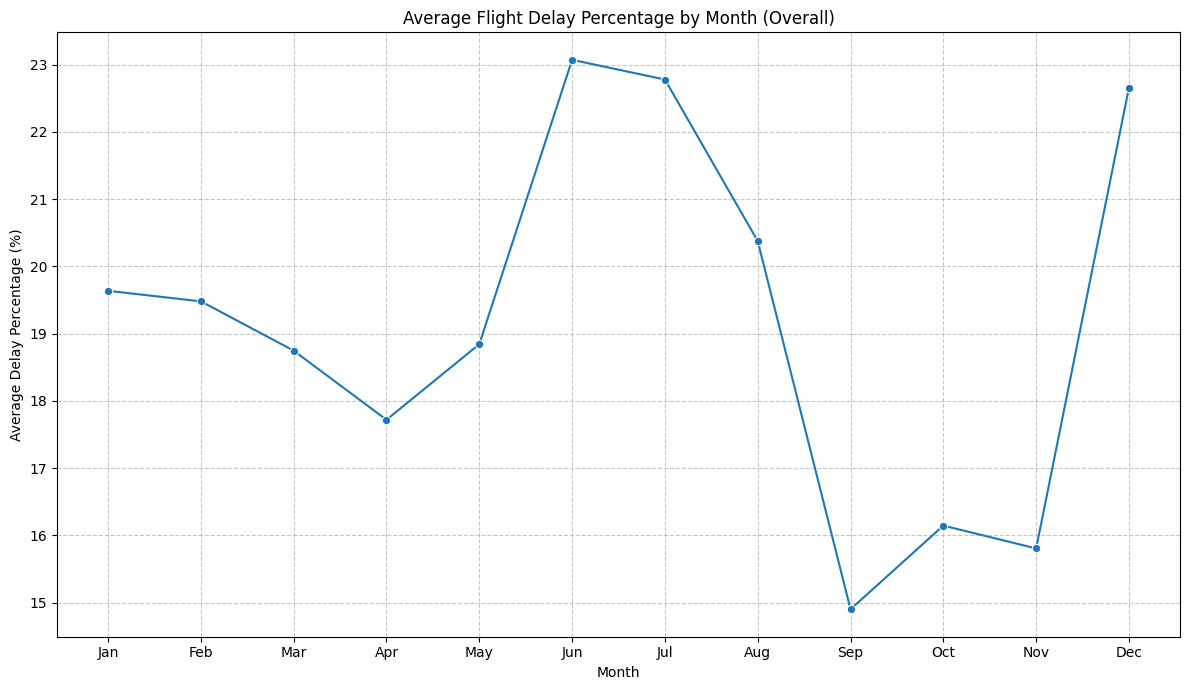

In [12]:
from pyspark.sql.functions import sum, col
import matplotlib.pyplot as plt
import seaborn as sns

# Group by month across all years to get overall monthly delay percentages
monthly_overall_delay_df = df.groupBy('month') \
                               .agg(sum('arr_del15').alias('total_delays'), \
                                    sum('arr_flights').alias('total_flights')) \
                               .orderBy('month')

# Calculate overall monthly delay percentage
monthly_overall_delay_df = monthly_overall_delay_df.withColumn(
    'delay_percentage',
    (col('total_delays') / col('total_flights')) * 100
)

# Convert to Pandas DataFrame for plotting
pandas_monthly_overall_delay = monthly_overall_delay_df.toPandas()

# Plotting the data
plt.figure(figsize=(12, 7))
sns.lineplot(x='month', y='delay_percentage', data=pandas_monthly_overall_delay, marker='o')
plt.title('Average Flight Delay Percentage by Month (Overall)')
plt.xlabel('Month')
plt.ylabel('Average Delay Percentage (%)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()